# 📓 Pre-Workshop Notebook 4: Cleaning and Processing Research Signals
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [1]:
# PROFILE SYNC
student_name = "Uzair Ahmad"
institution = "National University of Computer and Emerging Sciences, Pakistan"
active_notebook = "Notebook 04 — Signal Cleaning and Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Uzair Ahmad (National University of Computer and Emerging Sciences, Pakistan)
Current notebook: Notebook 04 — Signal Cleaning and Processing


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with signal data, your main responsibility is making sure the signal you are analyzing is clean and meaningful. AI tools are good at applying mathematical filters, but they sometimes miss edge cases — such as what to do when a recording contains a sudden spike from a movement artifact, or when a calculation produces an unexpected result.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to explain what its filtering steps do in plain language, and to flag any parts of the data that could not be processed cleanly.

---
## 🧠 Part A: Cleaning Raw Recordings
### Topic: Removing Noise, Filtering Signals, and Visualizing Frequency Content

This section introduces the core signal processing steps that transform raw, noisy recordings into clean data ready for analysis.

### 🧭 Activity A.1 — Filtering a Noisy Brain Signal

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a signal processing instructor explaining brain signal cleaning to a biology student. Write a Python script using SciPy and Matplotlib that demonstrates how to clean a noisy brain recording. The script should:
> 1. Generate 5 seconds of a simulated brain signal recorded at 500 measurements per second, combining a realistic 10 Hz brain rhythm, electrical interference at 60 Hz from the building's power supply, and a sudden large spike representing a participant's eye blink or muscle movement.
> 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed to accurately capture this signal.
> 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm while removing the 60 Hz electrical noise.
> 4. Add a simple threshold detector that flags and removes the eye blink spike from the recording.
> 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side.
> Use plain-language comments throughout explaining what each step does biologically and mathematically."

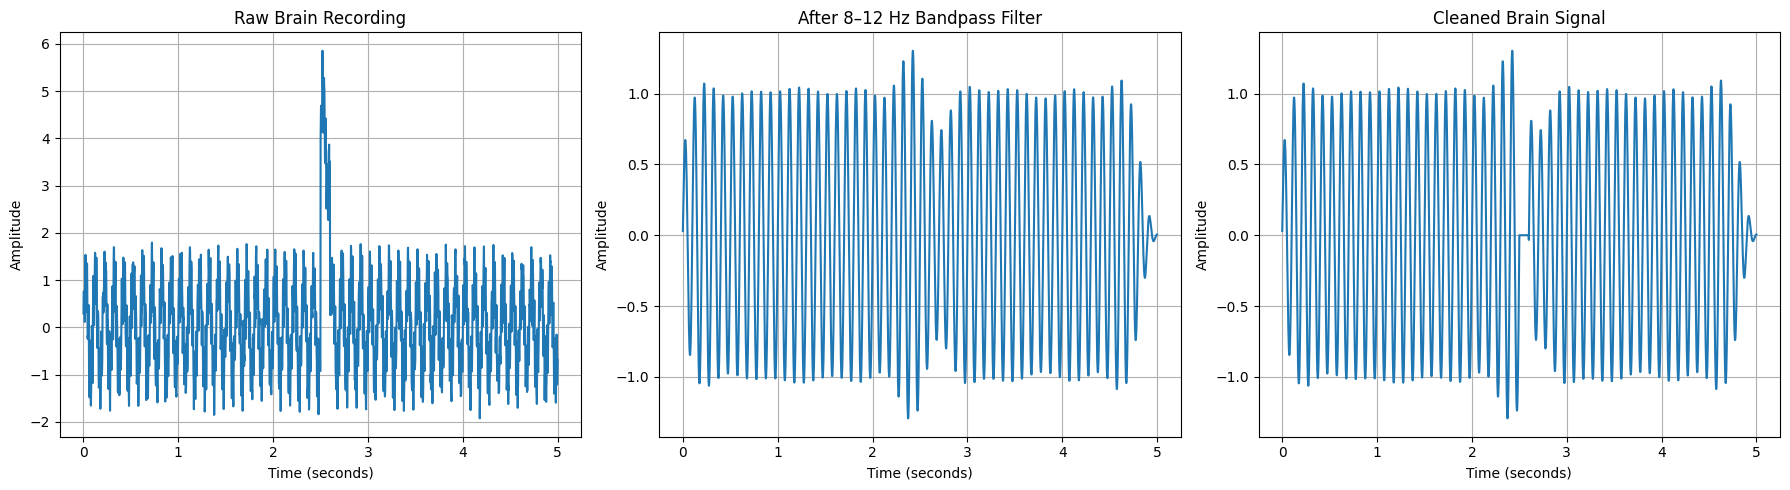

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ============================================================
# Simulating and Cleaning a Brain Signal
# ============================================================

# -----------------------------
# 1. Create a simulated recording
# -----------------------------

fs = 500          # Sampling rate: 500 measurements per second
duration = 5      # Record for 5 seconds
t = np.arange(0, duration, 1 / fs)

# A 10 Hz brain rhythm.
# Biologically, this represents a simplified rhythmic pattern
# of brain activity, such as an alpha-like rhythm.
brain_signal = np.sin(2 * np.pi * 10 * t)

# 60 Hz electrical interference.
# This represents electromagnetic noise from the building's
# power supply leaking into the recording.
power_noise = 0.6 * np.sin(2 * np.pi * 60 * t)

# Add some small random noise to make the recording more realistic.
random_noise = 0.15 * np.random.randn(len(t))

# Create a large sudden spike around 2.5 seconds.
# In a real brain recording, a large transient can be caused
# by an eye blink, muscle movement, or electrode disturbance.
blink = np.zeros_like(t)
blink_start = int(2.5 * fs)
blink[blink_start:blink_start + int(0.1 * fs)] = 4

# Combine everything to create the raw recording.
raw_signal = brain_signal + power_noise + random_noise + blink


# -----------------------------
# 2. Nyquist rule
# -----------------------------

# The Nyquist rule says that the sampling rate must be MORE THAN
# TWICE the highest frequency we want to accurately capture.
#
# Our highest important frequency is 60 Hz, so we need:
#
#       sampling rate > 2 * 60 = 120 samples/second
#
# We use 500 samples/second, which is comfortably above 120.
# This allows the 10 Hz brain rhythm and 60 Hz interference
# to be represented accurately in the digital recording.


# -----------------------------
# 3. Bandpass filter
# -----------------------------

# We want to keep the 10 Hz brain rhythm while removing frequencies
# far away from it, including the 60 Hz electrical interference.
#
# A bandpass filter lets frequencies inside a chosen range pass
# through and reduces frequencies outside that range.
#
# Here we keep approximately 8-12 Hz, which surrounds our
# simulated 10 Hz brain rhythm.

low_cutoff = 8
high_cutoff = 12

# Convert the cutoff frequencies into normalized frequencies
# required by SciPy's Butterworth filter.
nyquist = fs / 2
low = low_cutoff / nyquist
high = high_cutoff / nyquist

# Create a 4th-order Butterworth bandpass filter.
b, a = butter(4, [low, high], btype="band")

# Apply the filter in both directions.
# filtfilt avoids shifting the timing of the brain signal.
filtered_signal = filtfilt(b, a, raw_signal)


# -----------------------------
# 4. Detect and remove the large spike
# -----------------------------

# A simple threshold detector can identify unusually large
# amplitudes that are unlikely to represent the normal 10 Hz
# brain rhythm.
#
# Here we flag points whose absolute amplitude is larger than
# 2 times the normal brain rhythm's approximate amplitude.

threshold = 2.0
artifact_mask = np.abs(raw_signal) > threshold

# Make a copy of the filtered signal so that we can remove
# the detected artifact.
cleaned_signal = filtered_signal.copy()

# Replace detected artifact samples with zero.
# In a real analysis, researchers might instead interpolate
# across the artifact or remove the affected segment entirely.
cleaned_signal[artifact_mask] = 0


# -----------------------------
# 5. Plot the results
# -----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Raw recording: brain activity + electrical noise + artifact.
axes[0].plot(t, raw_signal)
axes[0].set_title("Raw Brain Recording")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

# After bandpass filtering:
# the 60 Hz electrical interference and other frequencies
# are strongly reduced, leaving the 10 Hz rhythm.
axes[1].plot(t, filtered_signal)
axes[1].set_title("After 8–12 Hz Bandpass Filter")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

# Final cleaned signal:
# the desired brain rhythm remains, while samples identified
# as unusually large artifacts have been removed.
axes[2].plot(t, cleaned_signal)
axes[2].set_title("Cleaned Brain Signal")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 🧭 Activity A.2 — Visualizing How Signals Change Over Time

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data visualization instructor. Write a Python script using SciPy and Matplotlib that shows how to create a time-frequency plot (spectrogram) of a brain signal. The script should:
> 1. Generate a signal that shifts from a slow rhythm (8 Hz, representing a resting brain state) for the first 2 seconds, then transitions to a faster rhythm (25 Hz, representing an active brain state) for the final 3 seconds.
> 2. Compute a spectrogram of this signal that shows how its frequency content changes over time.
> 3. Display the spectrogram with a color scale showing signal strength, with time on the horizontal axis and frequency on the vertical axis.
> Add plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot."

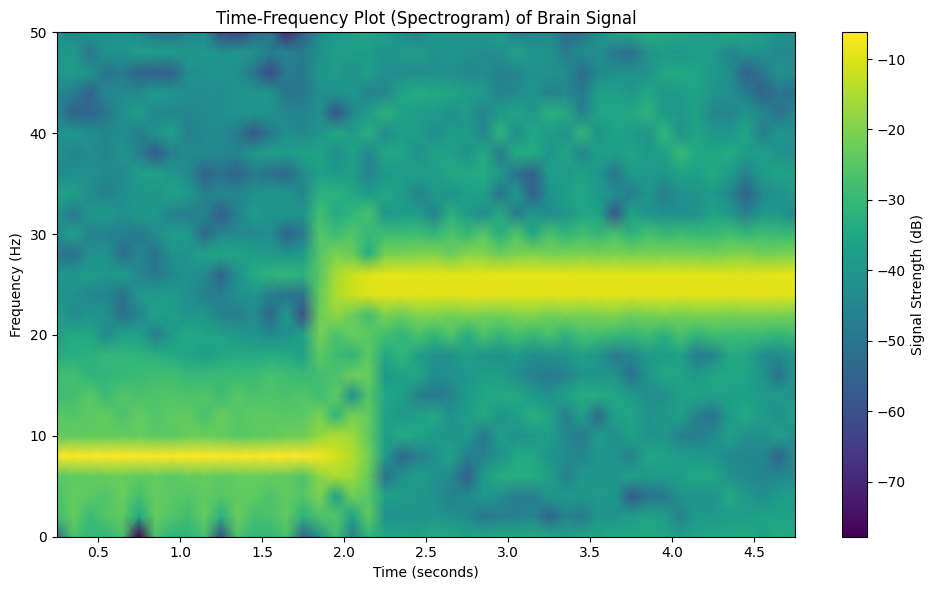

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# Time-Frequency Analysis of a Simulated Brain Signal
# ============================================================

# Sampling rate: 500 measurements per second.
# This is high enough to capture both 8 Hz and 25 Hz rhythms.
fs = 500

# Create 5 seconds of recording time.
duration = 5
t = np.arange(0, duration, 1 / fs)

# ------------------------------------------------------------
# 1. Create a brain signal that changes over time
# ------------------------------------------------------------

# First 2 seconds: an 8 Hz rhythm.
# This represents a slower, resting-like brain state.
slow_rhythm = np.sin(2 * np.pi * 8 * t)

# Final 3 seconds: a 25 Hz rhythm.
# This represents a faster, more active brain state.
fast_rhythm = np.sin(2 * np.pi * 25 * t)

# Start with the slow rhythm.
signal = slow_rhythm.copy()

# Replace the signal after 2 seconds with the faster rhythm.
signal[t >= 2] = fast_rhythm[t >= 2]

# Add a small amount of random noise to make the recording
# more similar to a real biological signal.
signal += 0.15 * np.random.randn(len(t))


# ------------------------------------------------------------
# 2. Calculate the spectrogram
# ------------------------------------------------------------

# A normal time-series plot shows amplitude changing over time,
# but it does not clearly tell us which frequencies are present
# at each moment.
#
# A spectrogram solves this problem by breaking the signal into
# short time windows and calculating the frequency content
# inside each window.
#
# This lets us see WHEN different brain rhythms are active.
frequencies, times, power = spectrogram(
    signal,
    fs=fs,
    nperseg=250,      # Number of samples in each analysis window
    noverlap=200      # Overlap between neighboring windows
)

# Keep frequencies up to 50 Hz so the two brain rhythms
# are easy to see.
frequency_limit = frequencies <= 50

frequencies = frequencies[frequency_limit]
power = power[frequency_limit, :]


# ------------------------------------------------------------
# 3. Display the spectrogram
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Convert power to decibels so weak and strong frequencies
# can be displayed on a useful color scale.
power_db = 10 * np.log10(power + 1e-10)

plt.pcolormesh(
    times,
    frequencies,
    power_db,
    shading="gouraud"
)

# Horizontal axis = when the brain activity occurred.
plt.xlabel("Time (seconds)")

# Vertical axis = frequency of the brain activity.
plt.ylabel("Frequency (Hz)")

plt.title("Time-Frequency Plot (Spectrogram) of Brain Signal")

# Color represents signal strength:
# brighter/stronger regions indicate that a frequency
# was more prominent at that particular time.
plt.colorbar(label="Signal Strength (dB)")

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the filtered outputs from Activity A.1, what happened to the 60 Hz noise and the blink spike? Did the filter affect the brain rhythm you were trying to preserve?


60 Hz noise: Mostly removed by the 8–12 Hz bandpass filter because 60 Hz is outside the target frequency range.
Blink spike: The filter reduced/smoothed it, but the separate threshold detector was needed to remove it properly.
10 Hz brain rhythm: Mostly preserved because it falls inside the 8–12 Hz passband.



* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from your Reference Guide. Explain in plain language what a spectrogram shows compared to a simple plot of voltage over time.


A simple voltage-over-time plot shows how the brain signal’s amplitude changes moment by moment. A spectrogram goes further: it shows which frequencies are present at each moment and how strong they are.

For example, in Activity A.2, we can see the signal change from 8 Hz during the first 2 seconds to 25 Hz during the last 3 seconds. So, a spectrogram helps us see when different brain rhythms occur, not just how the voltage changes.


---

## 💻 Part B: Writing Workflows That Handle Problems Gracefully
### Topic: Error Handling and Protecting Your Original Data

This section introduces two principles that make research workflows more reliable and reproducible: handling unexpected errors without crashing, and never overwriting your original data.

### 🧭 Activity B.1 — Building a Workflow That Does Not Crash

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software reliability instructor. Write a Python script that demonstrates how to build an analysis workflow that handles unexpected data problems gracefully, without crashing the entire analysis. The script should:
> 1. Create a dataset of measurements that intentionally includes some problematic values — such as a zero where a division will be performed, or a missing value.
> 2. Write an analysis loop that processes each measurement, using an error-handling structure (try/except/finally) to catch and log any problems it encounters, rather than stopping immediately.
> 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong and continues processing the remaining measurements.
> 4. Show clearly that the original dataset was not modified — the results are saved to a new, separate output.
> Use plain-language comments explaining why this approach is important for long analysis runs on large datasets."

In [4]:
# ============================================================
# Reliable Data Analysis Workflow with Error Handling
# ============================================================
#
# This example demonstrates how a research workflow can continue
# running even when some data values are problematic.
#
# Instead of crashing at the first error, the workflow:
#   1. Logs the problem.
#   2. Skips the bad measurement.
#   3. Continues processing the remaining data.
#
# This approach is important for long analyses on large datasets.
# If one bad value appears after hours of processing, we usually
# do not want to lose all progress and start over.
#
# ============================================================

# Original dataset.
#
# We intentionally include:
#   - A zero (causes division by zero)
#   - A missing value represented by None
#
measurements = [10, 5, 0, 20, None, 4, 8]

# Store analysis results in a NEW list.
#
# This protects the original data from accidental modification.
results = []

# Store error messages for later review.
error_log = []

print("Original dataset:")
print(measurements)
print()

# ------------------------------------------------------------
# Analysis loop
# ------------------------------------------------------------
#
# Example analysis:
# Compute 100 / measurement for each value.
#
# This will fail when measurement is 0 or None.
#
for index, value in enumerate(measurements):

    try:
        # Check for missing data.
        if value is None:
            raise ValueError("Missing measurement")

        # Example calculation.
        result = 100 / value

        # Save result to separate output.
        results.append(result)

        print(f"Measurement {index}: processed successfully")

    except ZeroDivisionError:
        message = (
            f"Measurement {index}: division by zero "
            f"(value = {value})"
        )

        error_log.append(message)
        print("ERROR:", message)

    except ValueError as err:
        message = (
            f"Measurement {index}: {err} "
            f"(value = {value})"
        )

        error_log.append(message)
        print("ERROR:", message)

    except Exception as err:
        # Catch any unexpected errors.
        message = (
            f"Measurement {index}: unexpected error -> {err}"
        )

        error_log.append(message)
        print("ERROR:", message)

    finally:
        # This block always runs.
        #
        # It is useful for cleanup tasks such as closing files,
        # saving progress, or recording status information.
        print(f"Finished handling measurement {index}\n")


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=" * 50)
print("Analysis complete")
print("=" * 50)

print("\nProcessed results:")
print(results)

print("\nLogged errors:")
for error in error_log:
    print("-", error)

print("\nOriginal dataset after analysis:")
print(measurements)

# Demonstrate that the original data was not changed.
print("\nOriginal data unchanged:",
      measurements == [10, 5, 0, 20, None, 4, 8])

Original dataset:
[10, 5, 0, 20, None, 4, 8]

Measurement 0: processed successfully
Finished handling measurement 0

Measurement 1: processed successfully
Finished handling measurement 1

ERROR: Measurement 2: division by zero (value = 0)
Finished handling measurement 2

Measurement 3: processed successfully
Finished handling measurement 3

ERROR: Measurement 4: Missing measurement (value = None)
Finished handling measurement 4

Measurement 5: processed successfully
Finished handling measurement 5

Measurement 6: processed successfully
Finished handling measurement 6

Analysis complete

Processed results:
[10.0, 20.0, 5.0, 25.0, 12.5]

Logged errors:
- Measurement 2: division by zero (value = 0)
- Measurement 4: Missing measurement (value = None)

Original dataset after analysis:
[10, 5, 0, 20, None, 4, 8]

Original data unchanged: True


### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What happened when the workflow encountered a problematic value? Did it stop, or did it continue? How was the problem recorded?

The workflow did not stop. When it encountered a problematic value, try/except caught the error, recorded the problem in the error log, and then continued processing the remaining measurements.

The finally block also ran after each measurement, ensuring the workflow completed its cleanup/status step regardless of whether an error occurred.



* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from your Reference Guide. Explain in plain language why a scientific workflow should never modify the original raw data files, even if it finds something wrong with them.

A scientific workflow should **never modify the original raw data** because the raw data is the original evidence. If something goes wrong during analysis, changing it could permanently remove or alter important information. Keeping the raw data unchanged lets researchers **re-run analyses, check errors, compare results, and reproduce the study**. Instead, problems should be recorded separately and cleaned/processed data should be saved as a **new file**.



---

## 📑 What Comes Next

Notebook 5 introduces machine learning and pattern recognition — how computers can learn to identify behavioral states or intentions from brain signal patterns.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 15 — Artifact removal | [ Enter Cell ID ] |
| Neuroscience | Concept 18 — Spectrogram | [ Enter Cell ID ] |
| Neuroscience | Concept 19 — Nyquist rule | [ Enter Cell ID ] |
| Computing | Concept 45 — Software libraries | [ Enter Cell ID ] |
| Computing | Concept 47 — Error handling | [ Enter Cell ID ] |
| Computing | Concept 50 — Protecting original data | [ Enter Cell ID ] |
